# Congressional Bills Data Cleaning

This notebook creates the `*.csv` data files included in this repo. The code is based on the [replication code](https://osf.io/gjt87/) from Egami et al. (2023).

In [1]:
import os
import pandas as pd
import numpy as np
import json

# Define directories
repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
os.chdir(repo_dir)

data_dir = os.path.join(repo_dir, "01_bills")
os.makedirs(data_dir, exist_ok=True)

## Load data from CAP

In [2]:
cap_path = os.path.join(data_dir, "CAP/US-Legislative-congressional_bills_19.3_3_3.csv")
if os.path.exists(cap_path):
    print(f"Using CAP data stored in {cap_path}...")
else:
    cap_path = "https://comparativeagendas.s3.amazonaws.com/datasetfiles/US-Legislative-congressional_bills_19.3_3_3.csv"
    print(f"Downloading CAP data from {cap_path}...")

cap = pd.read_csv(cap_path, low_memory=False)
print(f"Loaded CAP data, n = {len(cap)}")

# Correct bill IDs
cap["BillID_corrected"] = cap["cong"].astype(str) + "-" + cap["bill_type"].apply(lambda x: x.upper()) + "-" + cap["bill_no"].astype(str) 
cap_wrong_bill_id = cap[cap["bill_id"] != cap["BillID_corrected"]]
print(f"Corrected bill_id of {len(cap_wrong_bill_id)} observations")

# Remove duplicates based on bill ID
# cap_dup = cap[cap["BillID_corrected"].duplicated(keep=False)]
n_pre = len(cap)
cap.drop_duplicates(subset=["BillID_corrected"], inplace=True)
print(f"Dropped {n_pre - len(cap)} duplicates, n = {len(cap)}")

Using CAP data stored in /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills/CAP/US-Legislative-congressional_bills_19.3_3_3.csv...
Loaded CAP data, n = 468437
Corrected bill_id of 13361 observations
Dropped 4 duplicates, n = 468433


In [3]:
if ~((cap.loc[cap["cong"]==114,"chamber"].unique()) == [1,2]).all():
    print("Incorrect chamber encoding for cong=114")
    cap.loc[cap["cong"]==114,"chamber"] = cap.loc[cap["cong"]==114,"chamber"] + 1

cap["chamber"] = cap["chamber"].apply(lambda x: int(x == 2)) # House = 1, Senate = 2 in CAP
cap.loc[(cap["party"]==400) & (cap["name_full"]=="Anibal Acevedo-Vila"), "party"] = 100 # recode as Democratic (100)

Incorrect chamber encoding for cong=114


In [4]:
# Drop unnecessary columns
n_pre = len(cap.columns)
cap.drop(columns=[
        "id", "bill_id", "cong", "bill_type",  "bill_no", "name_full",
        "intr_date", "intr_month", "pap_majortopic", "pap_subtopic", "subtopic",
        "filter_plaw", "plaw_date", "plaw_no", "majority", "comment"
    ], inplace=True)
print(f"Dropped {n_pre - len(cap.columns)} columns")

# Rename columns for consistency
cap.rename(columns={
    'majortopic': 'Major',
    'description': 'Description',
    'year': 'Year',
    'party': 'Party', 
    'pass_h': 'PassH', 
    'pass_s': 'PassS',
    'chamber': 'Chamber'}, inplace=True)

Dropped 16 columns


In [5]:
major_text_pap = {
    1 : "Macroeconomics",
    2 : "Civil Rights, Minority Issues, and Civil Liberties",
    3 : "Health",
    4 : "Agriculture",
    5 : "Labor and Employment",
    6 : "Education",
    7 : "Environment",
    8 : "Energy",
    9 : "Immigration",
    10: "Transportation",
    12: "Law, Crime, and Family Issues",
    13: "Social Welfare",
    14: "Community Development and Housing Issues",
    15: "Banking, Finance, and Domestic Commerce",
    16: "Defense",
    17: "Space, Science, Technology, and Communications",
    18: "Foreign Trade",
    19: "International Affairs and Foreign Aid",
    20: "Government Operations",
    21: "Public Lands and Water Management",
    23: "Arts and Entertainment",
    99: "Other, Miscellaneous, and Human Interest"
}
# Add MajorText column 
cap["MajorText"] = cap["Major"].apply(lambda x: major_text_pap[x] if pd.notnull(x) else x)

In [6]:
# Rearrange columns
cap = cap[['BillID_corrected', 'Year', 'Major', 'MajorText', 'Description', 'Party', 'PassH', 'PassS', 'Chamber']]

# Display the first few rows of CAP data
cap.head()

,BillID_corrected,Year,Major,MajorText,Description,Party,PassH,PassS,Chamber
0,80-S-1873,1947,1.0,Macroeconomics,"A bill to maintain prosperity, promote full em...",200.0,0.0,0.0,1
1,80-HR-3000,1947,1.0,Macroeconomics,To amend the Employment Act of1946 so as to pr...,200.0,0.0,0.0,0
2,80-HR-4743,1947,1.0,Macroeconomics,"To maintain prosperity, to promote full employ...",200.0,0.0,0.0,0
3,80-S-525,1947,1.0,Macroeconomics,A bill to promote the progress of science and ...,100.0,0.0,0.0,1
4,80-HR-1815,1947,1.0,Macroeconomics,To promote the progress of science; to advance...,200.0,0.0,0.0,0


## Load variables from CBP

In [7]:
cbp_80_92_path = os.path.join(data_dir, "CBP/bills80-92.txt")
if os.path.exists(cbp_80_92_path):
    print(f"Using CBP 80-92 data stored in {cbp_80_92_path}...")
else:
    cbp_80_92_path = "http://congressionalbills.org/billfiles/bills80-92.zip"
    print(f"Downloading CBP 80-92 data from {cbp_80_92_path}...")
cbp_80_92 = pd.read_csv(cbp_80_92_path, sep='\t', encoding='latin-1', low_memory=False)

cbp_80_92.rename(columns={' ': 'Minor'}, inplace=True)
cbp_80_92.drop(columns=['id', 'ByReq', 'Commem', 'oldMajor', 'oldMinor', 'Month',  'ReferArr', 'Year', 'Age', 'ComMArr', 'DW2', 'LeadCham', 'LeadComm', 'LeadSubC'], inplace=True)
cbp_80_92["DW1"] = cbp_80_92["DW1"].apply(lambda x: np.nan if x == -99.0 else x)

Using CBP 80-92 data stored in /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills/CBP/bills80-92.txt...


In [8]:
cbp_93_114_path = os.path.join(data_dir, "CBP/bills93-114.csv")
if os.path.exists(cbp_93_114_path):
    print(f"Using CBP 93-114 data stored in {cbp_93_114_path}...")
else:
    cbp_93_114_path = "http://congressionalbills.org/billfiles/bills93-114.zip"
    print(f"Downloading CBP 93-114 data from {cbp_93_114_path}...")
cbp_93_114 = pd.read_csv(cbp_93_114_path, sep=';', encoding='latin-1', low_memory=False)

cbp_93_114.drop(columns='ImpBill', inplace=True)
# cbp_93_114 = cbp_93_114[cbp_80_92.columns.to_list()] # align columns, not needed but personal preference
cbp_93_114["DW1"] = cbp_93_114["DW1"].apply(lambda s: float(s.replace(",", ".") if isinstance(s, str) else s))

Using CBP 93-114 data stored in /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills/CBP/bills93-114.csv...


In [9]:
# Combine CBP datasets
cbp = pd.concat([cbp_80_92, cbp_93_114]).reset_index()
cbp.drop(columns='index', inplace=True)
print(f"Merged CBP data, n={len(cbp)}")

Merged CBP data, n=523841


In [10]:
# Correct BillID
cbp["BillType"] = cbp["BillType"].apply(lambda x: x.upper())
cbp["BillID_corrected"] = cbp["Cong"].astype(str) + "-" + cbp["BillType"] + "-" + cbp["BillNum"].astype(str) 
cbp_wrong_bill_id = cbp[cbp["BillID"] != cbp["BillID_corrected"]]
print(f"Corrected bill_id of {len(cbp_wrong_bill_id)} observations")
cbp.drop(columns="BillID", inplace=True)

# Remove duplicates in CBP based on BillID + choose the version with Major code similar to CAP
# If we decided to go with CBP data only, this needs to be updated
def remove_cbp_dup(cbp, cap):
    cbp_dup = cbp[cbp["BillID_corrected"].duplicated(keep=False)]
    for bill_id in cbp_dup["BillID_corrected"].unique():
        cap_major = cap.loc[cap["BillID_corrected"]==bill_id, "Major"].item()
        condition = (cbp["BillID_corrected"]==bill_id) & (cbp["Major"]!=cap_major)
        cbp = cbp[~condition]
        print(f"Dropped {condition.sum()} duplicates of {bill_id} with major topic that is inconsistent with that in CAP, {cap_major}")
    return(cbp)
    
# cbp_dup = cbp[cbp["BillID_corrected"].duplicated(keep=False)]
cbp = remove_cbp_dup(cbp, cap[["BillID_corrected", "Major"]])

# If both match, then keep the first even though they vary in other variables
n_pre = len(cbp)
cbp.drop_duplicates(subset=["BillID_corrected", "Major", "Minor"], inplace=True)
print(f"Dropped {n_pre - len(cbp)} duplicates based on bill_id, keeping first one if they vary in more than one variable, n = {len(cbp)}")

Corrected bill_id of 1 observations
Dropped 2 duplicates of 107-HR-5715 with major topic that is inconsistent with that in CAP, 12.0
Dropped 1 duplicates of 107-S-3051 with major topic that is inconsistent with that in CAP, 9.0
Dropped 1 duplicates of 107-S-3160 with major topic that is inconsistent with that in CAP, 15.0
Dropped 1 duplicates based on bill_id, keeping first one if they vary in more than one variable, n = 523836


In [11]:
# Add MajorText column 
cbp["MajorText"] = cbp["Major"].apply(lambda x: major_text_pap[x] if pd.notnull(x) else x)

In [12]:
# Impute missing DW1 scores
cbp.rename(columns={'DW1': 'DW1_NA'}, inplace=True)
print(f"Renamed original DW1 columns with missing data as DW1_NA.")

cbp["DW1"] = cbp["DW1_NA"]
dw1 = cbp.groupby(["NameFull","DW1"], group_keys=True).first()["DW1_NA"] # Egami averages over bills. We average over unique members. Currently a unique member is identified by their full name and dw1 score. TODO: verify if there is a unique identifier for members other than their name
dw1_mean = dw1.mean()
cbp.fillna(value={"DW1": dw1_mean}, inplace=True)
print(f"Impute the {np.isnan(cbp['DW1_NA']).sum()} missing scores in DW1_NA column using the mean, {dw1_mean:.4f}") 

Renamed original DW1 columns with missing data as DW1_NA.
Impute the 7161 missing scores in DW1_NA column using the mean, -0.0002


In [13]:
# Rename columns
cbp.rename(columns={'Title': 'Description'}, inplace=True)

# Rearrange columns
col_first = ['BillID_corrected', 'Major', 'MajorText', 'Description', 'Party', 'PassH', 'Chamber', 'PassS', 'DW1_NA', 'DW1']
col_remaining = [ col for col in cbp.columns if (col not in col_first) ]
cbp = cbp[col_first + col_remaining]

# Display the first few rows of CBP data
cbp.head()

,BillID_corrected,Major,MajorText,Description,Party,PassH,Chamber,PassS,DW1_NA,DW1,...,NameFull,NameLast,PooleID,Postal,State,URL,ChRef,RankRef,SubChRef,SubRankRef
0,80-HR-1,1.0,Macroeconomics,To reduce individual income tax payments,200.0,1,0,1,0.533,0.533,...,"Knutson, Harold",Knutson,5352.0,MN,33.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
1,80-HR-2,16.0,Defense,To amend the Armed Forces Leave Act of 1946 by...,200.0,0,0,0,0.224,0.224,...,"Van Zandt, James E.",Van Zandt,9645.0,PA,14.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
2,80-HR-3,16.0,Defense,To amend the Armed Forces Leave Act of 1946 to...,100.0,0,0,0,0.003,0.003,...,"Rogers, Dwight L.",Rogers,8023.0,FL,43.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
3,80-HR-4,12.0,"Law, Crime, and Family Issues",To safeguard the admission of evidence in cert...,100.0,1,0,0,-0.125,-0.125,...,"Hobbs, Sam",Hobbs,4471.0,AL,41.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN
4,80-HR-5,16.0,Defense,To protect honorably discharged veterans in th...,100.0,0,0,0,0.226,0.226,...,"Rankin, John E.",Rankin,7731.0,MS,46.0,http://beta.congress.gov/bill/80th-congress/ho...,NaN,NaN,NaN,NaN


## Merge CAP and CBP

In [14]:
# Merge CAP and CBP datasets
bills = cap.merge(cbp, on="BillID_corrected", suffixes=("_CAP", "_CBP"))
print(f"Merged CAP and CBP data, n = {len(bills)}")

Merged CAP and CBP data, n = 468433


In [15]:
from copy import deepcopy

def description_mismatch(bills):
    description_cap = pd.Series(deepcopy(bills["Description_CAP"]))
    description_cbp = pd.Series(deepcopy(bills["Description_CBP"]))
    
    description_cbp = description_cbp.apply(lambda x: x.lower())
    description_cap = description_cap.apply(lambda x: x.lower())
    description_cbp = description_cbp.str.replace('??????', '')
    description_cbp = description_cbp.str.replace('???', '')
    description_cbp = description_cbp.str.replace('""""', '')
    description_cap = description_cap.str.replace('_??', '')
    description_cap = description_cap.str.replace('""""', '')
    description_cbp = description_cbp.str.replace('`', '')
    description_cbp = description_cbp.str.replace("'s", "s") 
    description_cap = description_cap.str.replace('`', '')
    description_cap = description_cap.str.replace("'s", "s") 

    condition = description_cap!=description_cbp
    description_cbp[condition] = description_cbp[condition].str.replace('\' ', ' ')

    condition = description_cap!=description_cbp
    description_cbp[condition] = description_cbp[condition].str.replace(' \'', ' ')

    condition = description_cap!=description_cbp
    description_cap[condition] = description_cap[condition].str.replace('\' ', ' ')

    condition = description_cap!=description_cbp
    description_cap[condition] = description_cap[condition] .str.replace(' \'', ' ')
    
    condition = (description_cap!=description_cbp) & (description_cap.apply(lambda x: x[:6]=="A bill")) & (description_cbp.apply(lambda x: x[:6]=="An Act"))
    description_cap[condition] = description_cap[condition].str.replace("A bill","An Act", n=1) # around 1000 of those are different in how they start: "A bill" vs "An Act"
    
    condition = description_cap != description_cbp
    description_cap[condition] = description_cap[condition].str.replace("'", "")
    
    condition = description_cap!=description_cbp
    return condition

In [16]:
# Drop bills with missing data in key columns
condition = bills[["Major_CAP", "Description_CAP", "Party_CAP", "PassH_CAP", "PassS_CAP"]].isnull().any(axis=1)
bills = bills[~condition]
print(f"Dropped {condition.sum()} bills with missing data from Major_CAP, Description_CAP, Party_CAP, PassH_CAP, PassS_CAP, n = {len(bills)}")

# Drop bills with mismatching
bills["Major_CAP"] = bills["Major_CAP"].apply(lambda x: int(x))
bills["Major_CBP"] = bills["Major_CBP"].apply(lambda x: int(x))

bills["PassS_CAP"] = bills["PassS_CAP"].apply(lambda x: int(x))
bills["PassH_CAP"] = bills["PassH_CAP"].apply(lambda x: int(x))
condition = ((bills["Major_CAP"] != bills["Major_CBP"]) |
             (bills["Party_CAP"] != bills["Party_CBP"]) |
             (bills["PassS_CAP"] != bills["PassS_CBP"]) | 
             (bills["PassH_CAP"] != bills["PassH_CBP"]) |
             (bills["Chamber_CAP"] != bills["Chamber_CBP"]) | 
             description_mismatch(bills)) 
bills = bills[~condition] 
print(f"Dropped {condition.sum()} bills with mismatching Major, Description, Party, PassS, PassH in CAP and CBP, n = {len(bills)}")

bills.drop(columns=["Major_CBP", "MajorText_CBP", "Party_CBP", "PassH_CBP", "PassS_CBP", "Chamber_CBP"], inplace=True)

Dropped 29563 bills with missing data from Major_CAP, Description_CAP, Party_CAP, PassH_CAP, PassS_CAP, n = 438870
Dropped 10776 bills with mismatching Major, Description, Party, PassS, PassH in CAP and CBP, n = 428094


In [17]:
# Remove observations with Major=99 (~80,000)
condition = bills["Major_CAP"]==99
bills = bills[~condition]
print(f"Dropped {condition.sum()} observations with Major_CAP=99, n = {len(bills)}")

Dropped 76852 observations with Major_CAP=99, n = 351242


In [18]:
# Lowercase descriptions
bills["Description_CAP_lower"] = bills["Description_CAP"].apply(lambda x: x.lower())

# Remove duplicates based on Major and Description
n_pre = len(bills)
bills.drop_duplicates(subset='Description_CAP_lower', inplace=True)
print(f"Dropped {n_pre - len(bills)} duplicates that varied in bills_dup_col, n = {len(bills)}")

bills.drop(columns="Description_CAP_lower", inplace=True)

Dropped 122855 duplicates that varied in bills_dup_col, n = 228387


In [19]:
# Recode major topic IDs (1,...,10,12,...,21,23) to (1,...,10,11,...,20,21)
major_pap = bills[['Major_CAP', 'MajorText_CAP']].drop_duplicates().reset_index()

major_pap2ours = {} 
for i in range(len(major_pap)): 
    dict_key = major_pap.loc[i, 'Major_CAP']
    dict_val = i+1
    major_pap2ours[dict_key] = dict_val
bills["Major_CAP"] = bills["Major_CAP"].apply(lambda x: major_pap2ours[x])

major_text_ours = major_pap.set_index('Major_CAP')['MajorText_CAP'].to_dict()
major_text_ours

{1: 'Macroeconomics',
 2: 'Civil Rights, Minority Issues, and Civil Liberties',
 3: 'Health',
 4: 'Agriculture',
 5: 'Labor and Employment',
 6: 'Education',
 7: 'Environment',
 8: 'Energy',
 9: 'Immigration',
 10: 'Transportation',
 12: 'Law, Crime, and Family Issues',
 13: 'Social Welfare',
 14: 'Community Development and Housing Issues',
 15: 'Banking, Finance, and Domestic Commerce',
 16: 'Defense',
 17: 'Space, Science, Technology, and Communications',
 18: 'Foreign Trade',
 19: 'International Affairs and Foreign Aid',
 20: 'Government Operations',
 21: 'Public Lands and Water Management'}

In [20]:
# Drop columns with more than 10% missing values
n_pre = len(bills.columns)
# bills.dropna(axis=1, thresh=int(len(bills) * 0.9), inplace=True)
dw1_na = bills["DW1_NA"]
bills.dropna(axis=1, inplace=True)
bills["DW1_NA"] = dw1_na
print(f"Dropped {n_pre - len(bills.columns)} columns that contain any missing values except DW1_NA")

# Rename columns 
bills.rename(columns={
    'BillID_corrected': 'BillID',
    'Major_CAP': 'Major',
    'MajorText_CAP': 'MajorText',
    'Description_CAP': 'Description',
    'Party_CAP': 'Party', 
    'PassH_CAP': 'PassH', 
    'PassS_CAP': 'PassS',
    'Chamber_CAP': 'Chamber'}, inplace=True)

# Rearrange columns
col_first = [
    'BillID', 'Year', 
    'Major', 'MajorText', 
    'Party', 'PassH', 'PassS', 
    'Description', 'Description_CBP',
    'DW1', 'DW1_NA',
    ]
col_remaining = [ col for col in bills.columns if (col not in col_first) ]
bills = bills[col_first + col_remaining]

bills["State"] = bills["State"].apply(lambda x: int(x))

# Display the first few rows of cleaned data
bills.head()

Dropped 24 columns that contain any missing values except DW1_NA


,BillID,Year,Major,MajorText,Party,PassH,PassS,Description,Description_CBP,DW1,...,PLaw,ReportH,ReportS,Veto,ComC,CumHServ,MRef,NameFull,Postal,State
0,80-S-1873,1947,1,Macroeconomics,200.0,0,0,"A bill to maintain prosperity, promote full em...","A bill to maintain prosperity, promote full em...",-0.000215,...,0,0,0,0,0.0,0.0,1,"Capehart, Home",IN,22
1,80-HR-3000,1947,1,Macroeconomics,200.0,0,0,To amend the Employment Act of1946 so as to pr...,To amend the Employment Act of1946 so as to pr...,0.750000,...,0,0,0,0,0.0,12.0,1,"Hoffman, Clare E.",MI,23
2,80-HR-4743,1947,1,Macroeconomics,200.0,0,0,"To maintain prosperity, to promote full employ...","To maintain prosperity, to promote full employ...",0.544000,...,0,0,0,0,0.0,8.0,1,"Landis, Gerald W.",IN,22
3,80-S-525,1947,1,Macroeconomics,100.0,0,0,A bill to promote the progress of science and ...,A bill to promote the progress of science and ...,-0.000215,...,0,0,0,0,0.0,0.0,1,"Thomas, Elbert",UT,67
4,80-HR-1815,1947,1,Macroeconomics,200.0,0,0,To promote the progress of science; to advance...,To promote the progress of science; to advance...,0.095000,...,0,0,0,0,0.0,2.0,1,"Case, Clifford P.",NJ,12


In [21]:
chamber_code = {0: "House", 1: "Senate", }
bills["Chamber"] = bills["Chamber"].apply(lambda x: chamber_code[x])

party_code = {
    100: "Democrat", 
    112: "Conservative",
    200: "Republican",
    328: "Independent"}
bills["Party"] = bills["Party"].apply(lambda x: party_code[x])

In [22]:
# Save the cleaned data
print(f"Number of bills = {len(bills)}")
print(f"Number of variables = {len(bills.columns)}") 

bills.to_csv(os.path.join(data_dir, "bills.csv"), index=False)
majors = bills[['Major', 'MajorText']].drop_duplicates().reset_index()
majors.to_csv(os.path.join(data_dir, "majors.csv"))

print(f"Merged and cleaned bills.csv data and majors.csv saved at {data_dir}") 

Number of bills = 228387
Number of variables = 27
Merged and cleaned bills.csv data and majors.csv saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills


## Bills over years


Loaded bills data, n = 228387


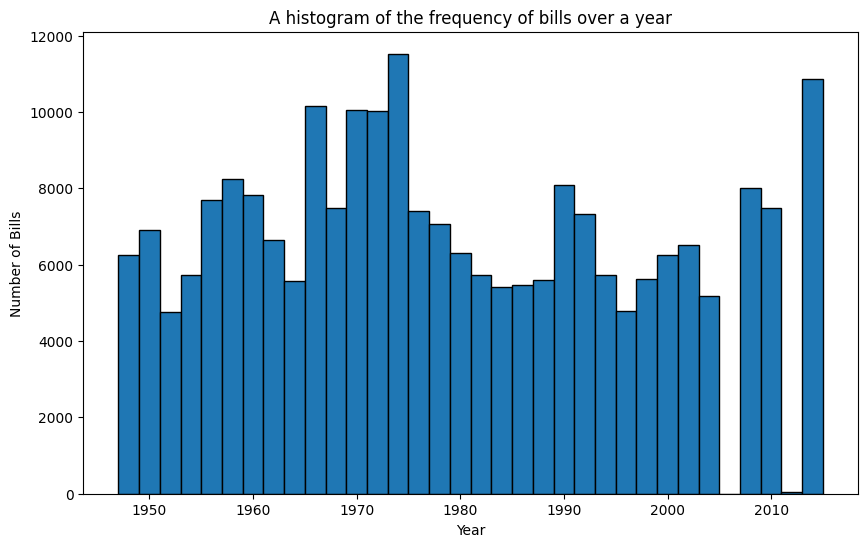

In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
bills = pd.read_csv(os.path.join(repo_dir, "01_bills/bills.csv"), low_memory=False)
print(f"Loaded bills data, n = {len(bills)}")

plt.figure(figsize=(10, 6))
bills['Year'].hist(bins=range(int(bills['Year'].min()), int(bills['Year'].max()) + 1, 2), edgecolor='black')
plt.title('A histogram of the frequency of bills over a year')
plt.xlabel('Year')
plt.ylabel('Number of Bills')
plt.grid(False)
plt.show()

## Generate Examples for Prompting

In [24]:
import os
import pandas as pd

# Define directories
repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
data_dir = os.path.join(repo_dir, "01_bills")
bills = pd.read_csv(os.path.join(data_dir, "bills.csv"))

seed = 123
n_examples = 5
# Bills used for few-shot prompting
examples = bills.groupby("Major").sample(n=1, random_state=seed).reset_index(drop=True)[:(n_examples*3)] # replace is False by default
examples01 = examples.iloc[:n_examples]
examples02 = examples.iloc[n_examples:(n_examples*2)]
examples03 = examples.iloc[(n_examples*2):]
examples01.to_csv(os.path.join(data_dir, "examples01.csv"), index=False)
examples02.to_csv(os.path.join(data_dir, "examples02.csv"), index=False)
examples03.to_csv(os.path.join(data_dir, "examples03.csv"), index=False)

condition = bills["BillID"].apply(lambda x: x not in examples["BillID"].to_list())
bills_without_examples = bills[condition]
print(f"Removing {len(examples)} examples from bills data ...")
bills_without_examples.to_csv(os.path.join(data_dir, "bills_without_examples.csv"), index=False)
print(f"bills_without_examples.csv, n = {len(bills_without_examples)}, saved at {data_dir}")

bills_without_examples_10000 = bills_without_examples.sample(n=10_000, random_state=seed)
bills_without_examples_10000.to_csv(os.path.join(data_dir, "bills_without_examples_10000.csv"), index=False)
print(f"bills_without_examples_10000.csv, n = {len(bills_without_examples_10000)}, saved at {data_dir}")

bills_without_examples_1000 = bills_without_examples_10000[:1000]
bills_without_examples_1000.to_csv(os.path.join(data_dir, "bills_without_examples_1000.csv"), index=False)
print(f"bills_without_examples_1000.csv, n = {len(bills_without_examples_1000)}, saved at {data_dir}")

bills_without_examples_9000 = bills_without_examples_10000[1000:]
bills_without_examples_9000.to_csv(os.path.join(data_dir, "bills_without_examples_9000.csv"), index=False)
print(f"bills_without_examples_9000.csv, n = {len(bills_without_examples_9000)}, saved at {data_dir}")


Removing 15 examples from bills data ...
bills_without_examples.csv, n = 228372, saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills
bills_without_examples_10000.csv, n = 10000, saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills
bills_without_examples_1000.csv, n = 1000, saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills
bills_without_examples_9000.csv, n = 9000, saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/01_bills
